# Machine Learning Part

In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prepare Clean Data

In [62]:
almond = pd.read_csv("Datasets/almond_clean.csv")

almond_onehot = almond.copy()

almond.head()

,length,width,thickness,area,perimeter,roundness,solidity,compactness,aspect_ratio,eccentricity,extent,convex_hull,type
0,321.807244,227.940628,127.759132,22619.0,643.813269,0.403849,0.973384,1.458265,1.923085,0.846328,0.681193,23237.5,MAMRA
1,321.807244,234.188126,128.199509,23038.0,680.984841,0.403849,0.957304,1.601844,1.923085,0.846328,0.656353,24065.5,MAMRA
2,321.807244,229.418610,125.796547,22386.5,646.943212,0.403849,0.967270,1.487772,1.923085,0.846328,0.683620,23144.0,MAMRA
3,321.807244,232.763153,125.918808,22578.5,661.227483,0.403849,0.965512,1.540979,1.923085,0.846328,0.685360,23385.0,MAMRA
4,321.807244,230.150742,107.253448,19068.0,624.842706,0.403849,0.951450,1.629395,1.923085,0.846328,0.714800,20041.0,MAMRA


## Encoding
Side note: Since we are dealing with almond classification, we don't need to onehot_encode the 'type' column. We don't need encoding at all.

In [63]:
#Use One-Hot Encoding to convert categorical variables into numerical format
almond_onehot = pd.get_dummies(almond_onehot, columns=['type'], drop_first=False)

In [64]:
almond_onehot

,length,width,thickness,area,perimeter,roundness,solidity,compactness,aspect_ratio,eccentricity,extent,convex_hull,type_MAMRA,type_REGULAR,type_SANORA
0,321.807244,227.940628,127.759132,22619.0,643.813269,0.403849,0.973384,1.458265,1.923085,0.846328,0.681193,23237.5,True,False,False
1,321.807244,234.188126,128.199509,23038.0,680.984841,0.403849,0.957304,1.601844,1.923085,0.846328,0.656353,24065.5,True,False,False
2,321.807244,229.418610,125.796547,22386.5,646.943212,0.403849,0.967270,1.487772,1.923085,0.846328,0.683620,23144.0,True,False,False
3,321.807244,232.763153,125.918808,22578.5,661.227483,0.403849,0.965512,1.540979,1.923085,0.846328,0.685360,23385.0,True,False,False
4,321.807244,230.150742,107.253448,19068.0,624.842706,0.403849,0.951450,1.629395,1.923085,0.846328,0.714800,20041.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2798,283.245347,192.709366,122.356506,18471.5,653.345233,0.500045,0.931000,1.838965,1.634305,0.789078,0.725739,19840.5,False,False,True
2799,283.245347,186.254745,118.708961,17213.5,581.688379,0.500045,0.952706,1.564234,1.634305,0.789078,0.714016,18068.0,False,False,True
2800,283.245347,186.196182,119.147224,17510.5,608.315795,0.500045,0.948821,1.681705,1.634305,0.789078,0.718999,18455.0,False,False,True
2801,283.245347,188.660828,120.634438,17941.0,630.759446,0.500045,0.944810,1.764701,1.634305,0.789078,0.738191,18989.0,False,False,True


## Scaling

### Using Standard Scaling

In [65]:
almond_standard_scaled = almond.copy()

#Standardize the numerical features
scaler = StandardScaler()
numerical_features = ['length', 'width', 'thickness', 'area', 'perimeter', 'aspect_ratio', 'convex_hull']
almond_standard_scaled[numerical_features] = scaler.fit_transform(almond_standard_scaled[numerical_features])

In [66]:
almond_standard_scaled

,length,width,thickness,area,perimeter,roundness,solidity,compactness,aspect_ratio,eccentricity,extent,convex_hull,type
0,0.586902,2.296827,1.166217,-0.282445,-0.433887,0.403849,0.973384,1.458265,1.109581,0.846328,0.681193,-0.313226,MAMRA
1,0.586902,2.548901,1.194369,-0.252039,-0.272686,0.403849,0.957304,1.601844,1.109581,0.846328,0.656353,-0.255059,MAMRA
2,0.586902,2.356461,1.040754,-0.299317,-0.420314,0.403849,0.967270,1.487772,1.109581,0.846328,0.683620,-0.319795,MAMRA
3,0.586902,2.491406,1.048569,-0.285384,-0.358367,0.403849,0.965512,1.540979,1.109581,0.846328,0.685360,-0.302865,MAMRA
4,0.586902,2.386001,-0.144665,-0.540135,-0.516157,0.403849,0.951450,1.629395,1.109581,0.846328,0.714800,-0.537782,MAMRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2798,-0.130134,0.875315,0.820840,-0.583422,-0.392550,0.500045,0.931000,1.838965,-0.704147,0.789078,0.725739,-0.551867,SANORA
2799,-0.130134,0.614884,0.587660,-0.674713,-0.703303,0.500045,0.952706,1.564234,-0.704147,0.789078,0.714016,-0.676386,SANORA
2800,-0.130134,0.612521,0.615677,-0.653160,-0.587829,0.500045,0.948821,1.681705,-0.704147,0.789078,0.718999,-0.649199,SANORA
2801,-0.130134,0.711964,0.710752,-0.621920,-0.490498,0.500045,0.944810,1.764701,-0.704147,0.789078,0.738191,-0.611685,SANORA


# Machine Learn Using Logistic Regression

## Predicting Almond Type

In [67]:
# Copy again
learning_data = almond_standard_scaled.copy()

In [68]:
# X = learning features
X = learning_data[['length', 'width', 'thickness', 'area', 'perimeter', 'roundness', 'solidity', 'compactness', 'aspect_ratio', 'eccentricity', 'extent', 'convex_hull']]

# y = target variable
y = learning_data[['type']]

feature_df = pd.DataFrame(X, columns=X.columns)
target_df = pd.DataFrame(y, columns=y.columns)

print("Features:")
feature_df

Features:


,length,width,thickness,area,perimeter,roundness,solidity,compactness,aspect_ratio,eccentricity,extent,convex_hull
0,0.586902,2.296827,1.166217,-0.282445,-0.433887,0.403849,0.973384,1.458265,1.109581,0.846328,0.681193,-0.313226
1,0.586902,2.548901,1.194369,-0.252039,-0.272686,0.403849,0.957304,1.601844,1.109581,0.846328,0.656353,-0.255059
2,0.586902,2.356461,1.040754,-0.299317,-0.420314,0.403849,0.967270,1.487772,1.109581,0.846328,0.683620,-0.319795
3,0.586902,2.491406,1.048569,-0.285384,-0.358367,0.403849,0.965512,1.540979,1.109581,0.846328,0.685360,-0.302865
4,0.586902,2.386001,-0.144665,-0.540135,-0.516157,0.403849,0.951450,1.629395,1.109581,0.846328,0.714800,-0.537782
...,...,...,...,...,...,...,...,...,...,...,...,...
2798,-0.130134,0.875315,0.820840,-0.583422,-0.392550,0.500045,0.931000,1.838965,-0.704147,0.789078,0.725739,-0.551867
2799,-0.130134,0.614884,0.587660,-0.674713,-0.703303,0.500045,0.952706,1.564234,-0.704147,0.789078,0.714016,-0.676386
2800,-0.130134,0.612521,0.615677,-0.653160,-0.587829,0.500045,0.948821,1.681705,-0.704147,0.789078,0.718999,-0.649199
2801,-0.130134,0.711964,0.710752,-0.621920,-0.490498,0.500045,0.944810,1.764701,-0.704147,0.789078,0.738191,-0.611685


In [69]:
print("Target Variable Values:", target_df['type'].unique())

Target Variable Values: <StringArray>
['MAMRA', 'SANORA', 'REGULAR']
Length: 3, dtype: str


## Train Test Splitting

In [70]:
#Split le data
#80% goes to training, 20% goes to testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

reg_count = y_test[y_test["type"]=="REGULAR"].value_counts()
mamra_count = y_test[y_test["type"]=="MAMRA"].value_counts()
sanora_count = y_test[y_test["type"]=="SANORA"].value_counts()

print("Number of Regular Almonds in Test Set:", reg_count.values[0])
print("Number of Mamra Almonds in Test Set:", mamra_count.values[0])
print("Number of Sanora Almonds in Test Set:", sanora_count.values[0])

Training set size: 2242
Testing set size: 561
Number of Regular Almonds in Test Set: 187
Number of Mamra Almonds in Test Set: 189
Number of Sanora Almonds in Test Set: 185


## =Training Part=

We want to predict what type of almond is given based on feautures that we know already.
Almond Types:
- Sanora
- Mamra
- Regular

Based on Features:
- Length
- Width
- Thickness
- Area 
- Perimeter
- Roundnes
- Solidity
- Compactness
- Aspect Ratio
- Eccentricity 
- Extent
- Convex Hull


### Using Logistic Regression

In [71]:
#Initialize the Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

#Train model
log_model.fit(X_train, y_train.values.ravel())

#Predict
log_pred = log_model.predict(X_test)

#View results
result_frame_log = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': log_pred.flatten()})
result_frame_log

,Actual,Predicted
0,MAMRA,MAMRA
1,MAMRA,MAMRA
2,MAMRA,MAMRA
3,REGULAR,REGULAR
4,MAMRA,MAMRA
...,...,...
556,SANORA,SANORA
557,REGULAR,REGULAR
558,SANORA,SANORA
559,SANORA,MAMRA


### Using Decision Tree

In [72]:
#Initialize the Decision Tree model
dec_tree_model = DecisionTreeClassifier(random_state=42)

#Train Model
dec_tree_model.fit(X_train, y_train.values.ravel())

#Predict
dec_tree_pred = dec_tree_model.predict(X_test)

#View results
result_frame_dec_tree = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': dec_tree_pred.flatten()})
result_frame_dec_tree

,Actual,Predicted
0,MAMRA,MAMRA
1,MAMRA,MAMRA
2,MAMRA,MAMRA
3,REGULAR,REGULAR
4,MAMRA,MAMRA
...,...,...
556,SANORA,SANORA
557,REGULAR,REGULAR
558,SANORA,SANORA
559,SANORA,SANORA


### Using K-Nearest Neighbors (KNN)

In [73]:
#Initialize the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

#Train Model
knn_model.fit(X_train, y_train.values.ravel())

#Predict
knn_pred = knn_model.predict(X_test)

#View results
result_frame_knn = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': knn_pred.flatten()})
result_frame_knn

,Actual,Predicted
0,MAMRA,MAMRA
1,MAMRA,MAMRA
2,MAMRA,MAMRA
3,REGULAR,REGULAR
4,MAMRA,MAMRA
...,...,...
556,SANORA,SANORA
557,REGULAR,REGULAR
558,SANORA,SANORA
559,SANORA,REGULAR


### Using Random Forest

In [74]:
#Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

#Train Model
rf_model.fit(X_train, y_train.values.ravel())

#Predict
rf_pred = rf_model.predict(X_test)

#View results
result_frame_rf = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': rf_pred.flatten()})
result_frame_rf

,Actual,Predicted
0,MAMRA,MAMRA
1,MAMRA,MAMRA
2,MAMRA,MAMRA
3,REGULAR,REGULAR
4,MAMRA,MAMRA
...,...,...
556,SANORA,SANORA
557,REGULAR,REGULAR
558,SANORA,SANORA
559,SANORA,SANORA


## =Result Analysis=

### Computing the Accuracy Score
This part measures how close the models predicted actual values

In [75]:
#Accuracy Score
log_acc = accuracy_score(y_test, log_pred)
dec_tree_acc = accuracy_score(y_test, dec_tree_pred)
knn_acc = accuracy_score(y_test, knn_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", log_acc)
print("Decision Tree Accuracy:", dec_tree_acc)
print("KNN Accuracy:", knn_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.7985739750445633
Decision Tree Accuracy: 0.9964349376114082
KNN Accuracy: 0.9518716577540107
Random Forest Accuracy: 1.0


### Computing Confusion Matrices
This part stores the wrong predictions made by each classification model used. Relative to what it is supposed to have predicted.

It follows the perfect format:

|   |Predicted Mamra|Predicted Regular|Predicted Sanora|
|:---|:---|:---|:---|
|Actually Mamra|mamra_count|0|0|
|Actually Regular|0|regular_count|0|
|Actually Sanora|0|0|sanora_count|

In [76]:
#Confusion Matrix
log_cm = confusion_matrix(y_test, log_pred)
dec_tree_cm = confusion_matrix(y_test, dec_tree_pred)
knn_cm = confusion_matrix(y_test, knn_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

print("Logistic Regression Confusion Matrix:\n", log_cm)
print("=" * 50)
print("Decision Tree Confusion Matrix:\n", dec_tree_cm)
print("=" * 50)
print("KNN Confusion Matrix:\n", knn_cm)
print("=" * 50)
print("Random Forest Confusion Matrix:\n", rf_cm)

Logistic Regression Confusion Matrix:
 [[162  21   6]
 [ 13 139  35]
 [  2  36 147]]
Decision Tree Confusion Matrix:
 [[188   1   0]
 [  1 186   0]
 [  0   0 185]]
KNN Confusion Matrix:
 [[188   1   0]
 [  0 173  14]
 [  1  11 173]]
Random Forest Confusion Matrix:
 [[189   0   0]
 [  0 187   0]
 [  0   0 185]]


### Report

In [77]:
log_report = classification_report(y_test, log_pred)
dec_tree_report = classification_report(y_test, dec_tree_pred)
knn_report = classification_report(y_test, knn_pred)
rf_report = classification_report(y_test, rf_pred)

print("Logistic Regression Classification Report:\n", log_report)
print("Decision Tree Classification Report:\n", dec_tree_report)
print("KNN Classification Report:\n", knn_report)
print("Random Forest Classification Report:\n", rf_report)

Logistic Regression Classification Report:
               precision    recall  f1-score   support

       MAMRA       0.92      0.86      0.89       189
     REGULAR       0.71      0.74      0.73       187
      SANORA       0.78      0.79      0.79       185

    accuracy                           0.80       561
   macro avg       0.80      0.80      0.80       561
weighted avg       0.80      0.80      0.80       561

Decision Tree Classification Report:
               precision    recall  f1-score   support

       MAMRA       0.99      0.99      0.99       189
     REGULAR       0.99      0.99      0.99       187
      SANORA       1.00      1.00      1.00       185

    accuracy                           1.00       561
   macro avg       1.00      1.00      1.00       561
weighted avg       1.00      1.00      1.00       561

KNN Classification Report:
               precision    recall  f1-score   support

       MAMRA       0.99      0.99      0.99       189
     REGULAR       

### Visualization
#### Note
I did not include the prediction vs actual values graph since the nature of the target data is discrete because of the classification analysis

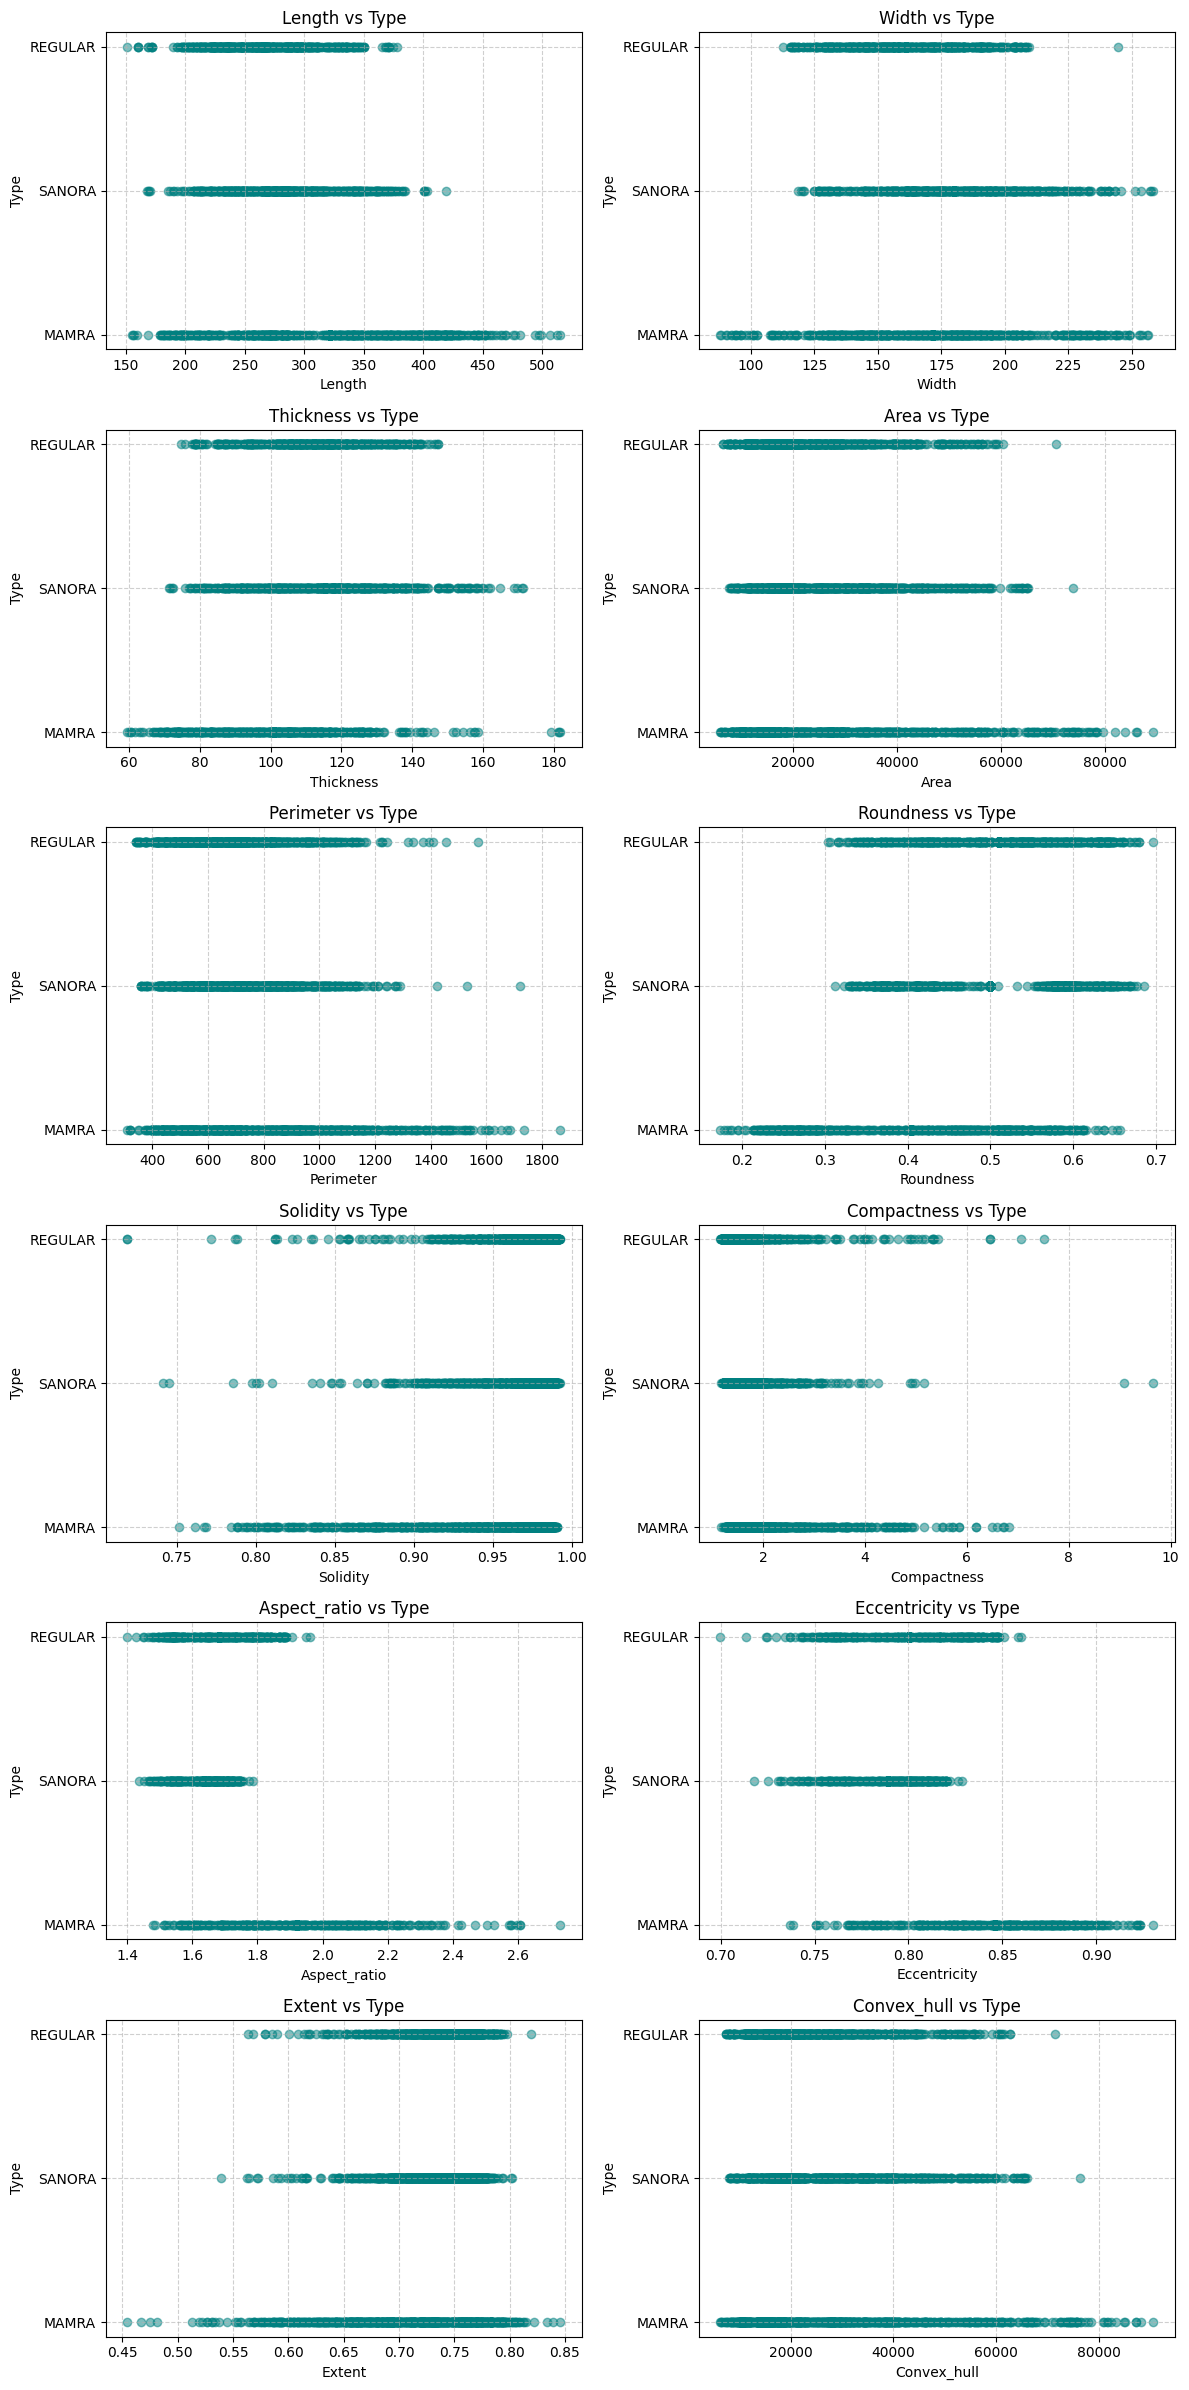

In [78]:
features = [
    'length', 'width', 'thickness', 'area', 'perimeter', 
    'roundness', 'solidity', 'compactness', 'aspect_ratio', 
    'eccentricity', 'extent', 'convex_hull'
]

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(12, 24))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(almond[col], almond['type'], alpha=0.5, color='teal')
    
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Type')
    axes[i].set_title(f'{col.capitalize()} vs Type')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

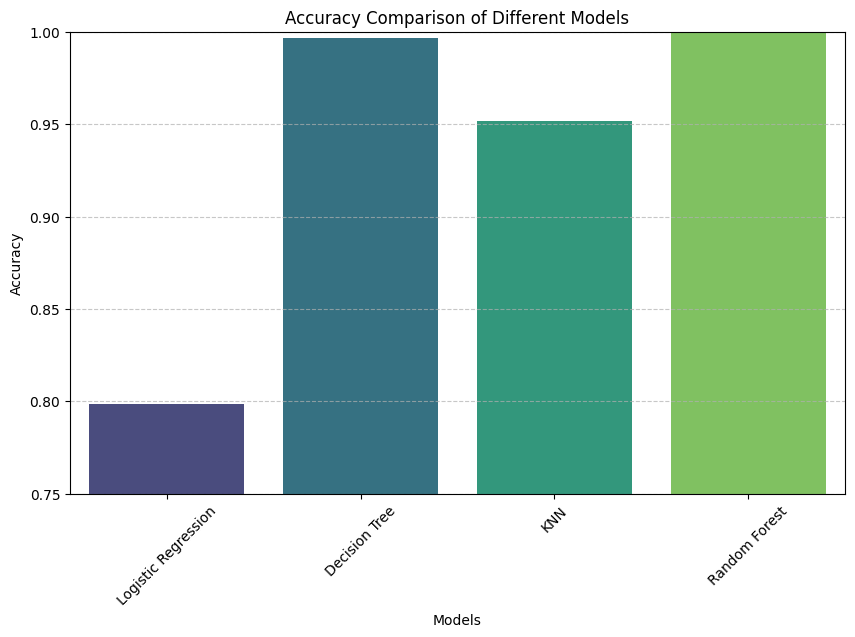

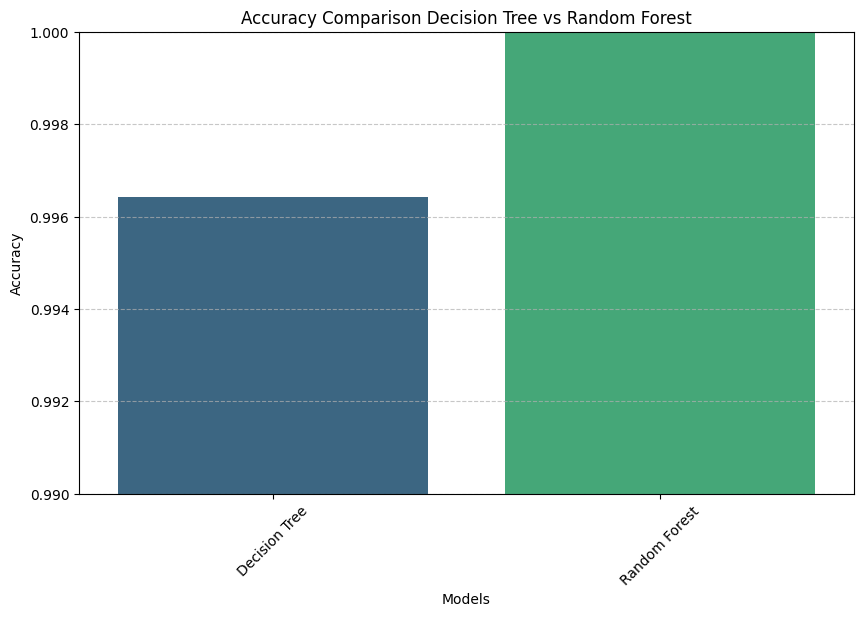

In [83]:
#Accuracy Comparison bar graph
accuracy_scores = {
    'Logistic Regression': log_acc,
    'Decision Tree': dec_tree_acc,
    'KNN': knn_acc,
    'Random Forest': rf_acc
}

plt.figure(figsize=(10, 6))
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette='viridis', hue=list(accuracy_scores.keys()), legend=False)
plt.ylim(0.75, 1.00)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Different Models')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

accuracy_scores = {
    'Decision Tree': dec_tree_acc,
    'Random Forest': rf_acc
}
plt.figure(figsize=(10, 6))
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette='viridis', hue=list(accuracy_scores.keys()), legend=False)
plt.ylim(0.99, 1.00)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison Decision Tree vs Random Forest')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# =Summary=

## Accuracy Comparison
The accuracy score measures the proportion of correct predictions made by each model out of all predictions. It is calculated as:  Accuracy = Number of Correct Predictions / Total Number of Predictions.

A higher accuracy indicates that the model is better at correctly classifying almond types. By comparing the accuracy scores of Logistic Regression, Decision Tree, KNN, and Random Forest, you can identify which model performs best overall on the test data.

| Model                | Accuracy |
|----------------------|----------|
| Logistic Regression  | 0.7986     |
| Decision Tree        | 0.9964     |
| KNN                  | 0.9519     |
| Random Forest        | 1.0000     |

---

## Confusion Comparison
A confusion matrix is a table that shows the number of correct and incorrect predictions for each class (almond type). Each row represents the actual class, while each column represents the predicted class.

The diagonal values (top-left to bottom-right) show correct predictions for each class. Off-diagonal values indicate misclassifications (e.g., Mamra predicted as Regular). A perfect model would have non-zero values only on the diagonal.

### Logistic Regression
| Actual \ Predicted | Mamra | Regular | Sanora |
|--------------------|-------|---------|--------|
| Mamra              | 162    | 21       | 6      |
| Regular            | 13     | 139     | 35      |
| Sanora             | 2     | 36       | 147      |

### Decision Tree
| Actual \ Predicted | Mamra | Regular | Sanora |
|--------------------|-------|---------|--------|
| Mamra              | 188    | 1       | 0      |
| Regular            | 1     | 186      | 0      |
| Sanora             | 0     | 0       | 185      |

### KNN
| Actual \ Predicted | Mamra | Regular | Sanora |
|--------------------|-------|---------|--------|
| Mamra              | 188    | 1       | 0      |
| Regular            | 0     | 173      | 14      |
| Sanora             | 1     | 11       | 173      |

### Random Forest
| Actual \ Predicted | Mamra | Regular | Sanora |
|--------------------|-------|---------|--------|
| Mamra              | 189    | 0       | 0      |
| Regular            | 0     | 187      | 0      |
| Sanora             | 0     | 0       | 185      |

The model correctly predicted the values on the diagonal. Off-diagonal values show misclassifications.

---

## Classification Reports
A classification report provides detailed metrics for each class: Precision (out of all predicted instances of a class, how many were correct?), Recall (out of all actual instances of a class, how many did the model correctly identify?), and F1-score (the harmonic mean of precision and recall).

High precision means few false positives. High recall means few false negatives. F1-score gives a single measure of model quality for each class.

### Logistic Regression
| Class   | Precision | Recall | F1-score | Support |
|---------|-----------|--------|----------|---------|
| Mamra   | 0.92      | 0.86   | 0.89     | 189      |
| Regular | 0.71      | 0.74   | 0.73     | 187      |
| Sanora  | 0.78      | 0.79   | 0.79     | 185       |
| **Avg/Total** | 0.80 | 0.80 | 0.80 | 561      |

### Decision Tree
| Class   | Precision | Recall | F1-score | Support |
|---------|-----------|--------|----------|---------|
| Mamra   | 0.99      | 0.99   | 0.99     | 189      |
| Regular | 0.99      | 0.99   | 0.99     | 187      |
| Sanora  | 1.00      | 1.00   | 1.00     | 185       |
| **Avg/Total** | 1.00 | 1.00 | 1.00 | 561      |

### KNN
| Class   | Precision | Recall | F1-score | Support |
|---------|-----------|--------|----------|---------|
| Mamra   | 0.99      | 0.99   | 0.99     | 189      |
| Regular | 0.94      | 0.93   | 0.93     | 187      |
| Sanora  | 0.93      | 0.94   | 0.93     | 185       |
| **Avg/Total** | 0.95 | 0.95 | 0.95 | 561      |

### Random Forest
| Class   | Precision | Recall | F1-score | Support |
|---------|-----------|--------|----------|---------|
| Mamra   | 1.0      | 1.00   |1.0     | 189      |
| Regular | 1.00      | 1.0   | 1.0    | 187      |
| Sanora  | 1.00      | 1.00   | 1.00     | 185       |
| **Avg/Total** | 1.0 | 1.0 | 1.0 | 561      |

Each row shows the metrics for a specific almond type. The 'Avg/Total' row summarizes the overall performance across all classes.

---

**Conclusion:**  By analyzing these tables, you can determine which model is most accurate, where misclassifications occur, and how well each model performs for each almond type. This comprehensive evaluation helps in selecting the best model and understanding its strengths and weaknesses for almond classification.

# Exporting the model

In [80]:
import joblib

#Train
final_model = RandomForestClassifier()
final_model.fit(X_train, y_train.values.ravel())

#Predict
final_predict = final_model.predict(X_test)

#Evaluate
final_acc = accuracy_score(y_test, final_predict)
final_cm = confusion_matrix(y_test, final_predict)
final_report = classification_report(y_test, final_predict)

print("Final Accuracy: \n", final_acc)
print("Confusion Matrix: \n", final_cm)
print("Report: \n", final_report)

joblib.dump(final_model, "AlmondClassifier_RandomForest.pkl")

Final Accuracy: 
 1.0
Confusion Matrix: 
 [[189   0   0]
 [  0 187   0]
 [  0   0 185]]
Report: 
               precision    recall  f1-score   support

       MAMRA       1.00      1.00      1.00       189
     REGULAR       1.00      1.00      1.00       187
      SANORA       1.00      1.00      1.00       185

    accuracy                           1.00       561
   macro avg       1.00      1.00      1.00       561
weighted avg       1.00      1.00      1.00       561



['AlmondClassifier_RandomForest.pkl']